# Resort Churn Prediction - CatBoost + Optuna

**Goal.** Predict the binary `Churned` flag for resort guests in `resort_test.csv` and write a `submission.csv` file containing `GuestID,Churned` rows.

**Workflow.**
1. Load the raw train / test CSVs straight from GitHub.
2. Clean the data: fix the corrupted-decimal amenity values, parse `BookingDate`, split the composite `Room` code, and add missingness indicators.
3. Export the cleaned + engineered training frame to `cleaned_data.csv`.
4. Build a `ColumnTransformer` so the *same* preprocessing is applied to train and test.
5. Establish a baseline CatBoost score with 5-fold stratified CV (F1 macro).
6. Hyper-parameter tune CatBoost with **Optuna** (TPE sampler, F1 macro objective, 5-fold stratified CV). The model is built on the default 0.5 decision rule.
7. Re-fit the tuned model on the full training set; inspect the in-sample report and feature importances.
8. Choose the **decision threshold** on out-of-fold probabilities by sweeping a single cut for the best macro F1, and compare it against the 0.5 baseline.
9. Measure a **native-categorical** CatBoost variant (`cat_features`) against the one-hot pipeline on the same out-of-fold comparison.
10. Produce `submission.csv` using the chosen threshold.

Each section is self-contained and re-runnable from the top.

## 1. Imports

Standard PyData stack plus `catboost` (the single model family we use) and `optuna` for hyper-parameter search.

In [1]:
# If anything is missing, uncomment:
# %pip install pandas numpy scikit-learn catboost optuna matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the data

We load directly from the GitHub `raw.githubusercontent.com` host - the `github.com/.../blob/...` URL would return rendered HTML rather than the CSV bytes.

In [2]:
TRAIN_URL = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_train.csv"
TEST_URL  = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_test.csv"

train_raw = pd.read_csv(TRAIN_URL)
test_raw  = pd.read_csv(TEST_URL)

print(f"Train shape: {train_raw.shape}")
print(f"Test  shape: {test_raw.shape}")
train_raw.head()

Train shape: (6954, 21)
Test  shape: (1739, 20)


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,...,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,...,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,...,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,...,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,...,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,...,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


### 2a. Quick look at the schema

Note the mix of types and the very high missing-rate / outlier behaviour in some of the spend columns (`Dining`, `Spa`, `Entertainment`, ...). We handle these in the cleaning step.

In [3]:
summary = pd.DataFrame({
    "dtype": train_raw.dtypes,
    "missing": train_raw.isna().sum(),
    "missing_pct": (train_raw.isna().mean() * 100).round(1),
    "nunique": train_raw.nunique(),
})
summary

,dtype,missing,missing_pct,nunique
GuestID,int64,0,0.0,6954
BookingDate,object,0,0.0,658
PromoCode,object,3245,46.7,2
Region,object,169,2.4,3
AllInclusive,float64,168,2.4,2
Room,object,386,5.6,5297
PackageType,object,153,2.2,3
Age,float64,476,6.8,80
VIP,float64,158,2.3,2
RoomService,float64,464,6.7,1197


In [4]:
# Target balance - modestly imbalanced, so we use F1 macro as the primary CV metric.
train_raw["Churned"].value_counts(normalize=True).rename("share").to_frame()

,share
Churned,
1,0.503595
0,0.496405


## 3. Cleaning + feature engineering

Everything that needs raw-row context (string parsing, date math, `Room` decomposition, the row-wise amenity fix) lives in a single pure function `engineer(df)` so that it can be applied identically to train and test.

### Amenity outlier rule

The amenity-spend columns - `RoomService`, `Dining`, `Retail`, `Spa`, `Entertainment` - are *supposed* to be integers. The dataset contains a handful of absurd six-figure values like `336519.8436426201`, and every one of them has a non-zero fractional part. We treat that as a data-entry corruption rather than a real spend value.

**Per-row rule** (applies independently to each guest):

1. A cell is **bad** if it is missing *or* has a non-zero fractional part.
2. If at least one of the 5 amenity cells is **good** (clean integer), replace every bad cell in that row with the *rounded mean* of the good cells - assume the guest used the amenity but the value got mangled in recording.
3. If **all 5** cells are bad, we have no information to lean on, so fill them all with **0** (assume no amenity usage).

Other engineering:

* **`BookingDate`** -> year, month, day-of-week, is-weekend, days-since-earliest-booking.
* **`Room`** (e.g. "G/630/S") -> split into `RoomBuilding`, `RoomNumber`, `RoomSection`.
* **`Age`** - the dataset uses `0.0` as a sentinel for unknown, so replace it with NaN and let the imputer handle it. Also derive an `AgeKnown` flag.
* **Spend aggregates** - `TotalSpend`, `TotalSpend_log`, `SpendCategories`, and per-column `log1p` features.
* **Missing-indicator columns** for the fields where NaN itself is a signal (`PromoCode`, `AllInclusive`, `Region`).
* **Drop** `BookingDate` and the original `Room` string (replaced by their derived columns).

In [5]:
AMENITIES = ["RoomService", "Dining", "Retail", "Spa", "Entertainment"]
EARLIEST_BOOKING = pd.to_datetime(train_raw["BookingDate"], errors="coerce").min()
print(f"Earliest booking date in train: {EARLIEST_BOOKING.date()}")

Earliest booking date in train: 2023-01-01


In [6]:
def fix_amenity_decimals(df: pd.DataFrame, cols=AMENITIES) -> pd.DataFrame:
    """Row-wise repair of corrupted decimal values in the amenity-spend columns.

    For each row:
      * A cell is "bad" if it is NaN OR has a non-zero fractional part.
      * If 1-4 cells are bad, fill each bad cell with round(mean(good cells)).
      * If all 5 cells are bad, fill with 0.

    Returns a new dataframe with the amenity columns cleaned and cast to int.
    """
    out = df.copy()
    vals = out[cols].astype(float)
    # NaN comparisons return False in pandas, so handle NaN explicitly.
    is_bad = vals.isna() | ((vals % 1) != 0)
    # Mean of just the good cells per row; NaN where every cell is bad.
    good_only = vals.mask(is_bad)
    row_means = good_only.mean(axis=1)
    # All-bad rows: fill 0. Otherwise: rounded row mean.
    fill_values = row_means.round().fillna(0)
    # Broadcast fill_values across the bad cells; keep good cells as-is.
    fixed = vals.where(~is_bad, fill_values, axis=0)
    out[cols] = fixed.astype(int)
    n_bad_cells = int(is_bad.values.sum())
    n_all_bad_rows = int(is_bad.all(axis=1).sum())
    print(f"  fixed {n_bad_cells:,} corrupted amenity cells"
          f" ({n_all_bad_rows:,} rows had all 5 columns bad -> filled with 0)")
    return out


def engineer(df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    """Clean + feature-engineer a raw resort dataframe. Returns a new df."""
    if label:
        print(f"[{label}] engineering...")
    out = df.copy()

    # --- Amenity decimal repair (the big-outlier fix) ---
    out = fix_amenity_decimals(out)

    # --- BookingDate ---
    bd = pd.to_datetime(out["BookingDate"], errors="coerce")
    out["BookingYear"]      = bd.dt.year
    out["BookingMonth"]     = bd.dt.month
    out["BookingDayOfWeek"] = bd.dt.dayofweek
    out["BookingIsWeekend"] = bd.dt.dayofweek.isin([5, 6]).astype("Int64")
    out["DaysSinceFirstBooking"] = (bd - EARLIEST_BOOKING).dt.days

    # --- Room: split "G/630/S" -> building / number / section ---
    room_parts = out["Room"].fillna("").str.split("/", expand=True)
    out["RoomBuilding"] = room_parts[0].replace("", np.nan)
    out["RoomNumber"]   = pd.to_numeric(room_parts[1], errors="coerce")
    out["RoomSection"]  = room_parts[2].replace("", np.nan) if room_parts.shape[1] > 2 else np.nan

    # --- Age: 0.0 is a sentinel for "unknown" ---
    age = out["Age"].replace(0.0, np.nan)
    out["Age"]      = age
    out["AgeKnown"] = age.notna().astype(int)

    # --- Spend aggregates / log features ---
    for col in AMENITIES:
        out[f"{col}_log"] = np.log1p(out[col])
    out["TotalSpend"]      = out[AMENITIES].sum(axis=1)
    out["TotalSpend_log"]  = np.log1p(out["TotalSpend"])
    out["SpendCategories"] = (out[AMENITIES] > 0).sum(axis=1)

    # --- Missing-indicator flags where NaN is meaningful ---
    out["PromoCode_missing"]    = out["PromoCode"].isna().astype(int)
    out["Region_missing"]       = out["Region"].isna().astype(int)
    out["AllInclusive_missing"] = out["AllInclusive"].isna().astype(int)

    # --- Drop columns we no longer need ---
    out = out.drop(columns=["BookingDate", "Room"])
    return out


train_fe = engineer(train_raw, label="train")
test_fe  = engineer(test_raw,  label="test")

print("After feature engineering:")
print("  train:", train_fe.shape)
print("  test :", test_fe.shape)
train_fe.head()

[train] engineering...
  fixed 2,078 corrupted amenity cells (0 rows had all 5 columns bad -> filled with 0)
[test] engineering...
  fixed 523 corrupted amenity cells (0 rows had all 5 columns bad -> filled with 0)
After feature engineering:
  train: (6954, 39)
  test : (1739, 38)


,GuestID,PromoCode,Region,AllInclusive,PackageType,Age,VIP,RoomService,Dining,Retail,...,Dining_log,Retail_log,Spa_log,Entertainment_log,TotalSpend,TotalSpend_log,SpendCategories,PromoCode_missing,Region_missing,AllInclusive_missing
0,619623,NaN,Americas,0.0,Relaxation,NaN,0.0,0,0,0,...,0.0,0.000000,0.000000,0.000000,0,0.000000,0,1,0,0
1,776250,NaN,Americas,1.0,Relaxation,17.0,0.0,0,0,0,...,0.0,0.000000,0.000000,0.000000,0,0.000000,0,1,0,0
2,932709,NaN,Americas,NaN,Wellness,35.0,0.0,0,0,0,...,0.0,0.000000,0.000000,0.000000,0,0.000000,0,1,0,1
3,771839,PromoA,Europe,1.0,Adventure,26.0,0.0,0,0,0,...,0.0,0.000000,0.000000,0.000000,0,0.000000,0,0,0,0
4,755501,PromoA,Americas,0.0,Relaxation,13.0,0.0,0,0,60,...,0.0,4.110874,0.693147,8.546364,5208,8.558143,3,0,0,0


In [7]:
# Sanity-check the amenity fix: post-cleaning, every amenity cell should be a
# non-negative integer with no NaNs.
amen_after = train_fe[AMENITIES]
print("Amenity column stats after cleaning:")
print(amen_after.describe().round(1).T[["min", "max", "mean", "std"]])
print(f"\nAny NaN remaining in amenity cols? {amen_after.isna().any().any()}")
print(f"Any non-integer values remaining?  {((amen_after % 1) != 0).any().any()}")

Amenity column stats after cleaning:
               min      max   mean     std
RoomService    0.0  14327.0  240.0   692.8
Dining         0.0  29813.0  433.1  1541.3
Retail         0.0  12253.0  176.0   557.0
Spa            0.0  18572.0  304.7  1097.0
Entertainment  0.0  20336.0  296.6  1098.4

Any NaN remaining in amenity cols? False
Any non-integer values remaining?  False


### 3a. Export the cleaned training data

Snapshot the cleaned + feature-engineered training frame to `cleaned_data.csv` *before* it goes through the `ColumnTransformer` (scaling / one-hot). This keeps the file human-readable - original column names, raw category strings, NaNs intact - so it is easy to inspect in Excel or load into a separate analysis.

In [8]:
CLEANED_PATH = "cleaned_data.csv"
train_fe.to_csv(CLEANED_PATH, index=False)
print(f"Wrote {CLEANED_PATH}: {train_fe.shape[0]:,} rows x {train_fe.shape[1]} columns")
print("Columns:")
for c in train_fe.columns:
    print(f"  - {c}")

Wrote cleaned_data.csv: 6,954 rows x 39 columns
Columns:
  - GuestID
  - PromoCode
  - Region
  - AllInclusive
  - PackageType
  - Age
  - VIP
  - RoomService
  - Dining
  - Retail
  - Spa
  - Entertainment
  - LoyaltyPoints
  - SurveyScore
  - DaysSinceEmail
  - BookingChannel
  - AgeGroup
  - ReferralSource
  - Churned
  - BookingYear
  - BookingMonth
  - BookingDayOfWeek
  - BookingIsWeekend
  - DaysSinceFirstBooking
  - RoomBuilding
  - RoomNumber
  - RoomSection
  - AgeKnown
  - RoomService_log
  - Dining_log
  - Retail_log
  - Spa_log
  - Entertainment_log
  - TotalSpend
  - TotalSpend_log
  - SpendCategories
  - PromoCode_missing
  - Region_missing
  - AllInclusive_missing


## 4. Build the preprocessing pipeline

Numeric columns -> median impute + standard scale.
Categorical columns -> most-frequent impute + one-hot encode (`handle_unknown='ignore'` so unseen categories in the test set do not crash).

In [9]:
TARGET = "Churned"
ID_COL = "GuestID"

y = train_fe[TARGET].astype(int).values
X = train_fe.drop(columns=[TARGET, ID_COL])
X_test = test_fe.drop(columns=[ID_COL])
# Guarantee identical column order between train and test.
X_test = X_test[X.columns]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols     = [c for c in X.columns if c not in categorical_cols]

print(f"{len(numeric_cols)} numeric columns")
print(f"{len(categorical_cols)} categorical columns -> {categorical_cols}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

29 numeric columns
8 categorical columns -> ['PromoCode', 'Region', 'PackageType', 'BookingChannel', 'AgeGroup', 'ReferralSource', 'RoomBuilding', 'RoomSection']


## 5. Baseline CatBoost (5-fold CV)

The previous version ran a seven-model bake-off here. CatBoost won every time, so the bake-off is gone and we go straight to a single CatBoost with default-ish settings. Its 5-fold stratified F1 macro is the **baseline** that both the Optuna-tuned model (section 6) and the threshold choice (section 9) are compared against.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Single CatBoost with sensible defaults - this is the BASELINE the tuned model
# and the threshold choice are measured against. (The old multi-model bake-off
# has been removed: CatBoost was consistently the strongest family, so we go
# straight to it.)
baseline_model = CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.05,
    random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
)
baseline_pipe = Pipeline([("prep", preprocessor), ("model", baseline_model)])
baseline_scores = cross_val_score(baseline_pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
BASELINE_CV_F1 = baseline_scores.mean()
print(f"Baseline CatBoost (default params)  "
      f"F1 macro = {BASELINE_CV_F1:.4f}  +/- {baseline_scores.std():.4f}")

Baseline CatBoost (default params)  F1 macro = 0.8533  +/- 0.0078


## 6. Hyper-parameter tuning with Optuna - CatBoost

Each Optuna trial samples a set of CatBoost hyper-parameters, runs 5-fold stratified CV with the same preprocessor, and returns the mean F1 macro. The model is tuned on the **default 0.5 decision rule** - the operating threshold is chosen later (section 9), not during tuning.

Search space:
* `iterations`, `depth`, `learning_rate` - capacity / step size.
* `l2_leaf_reg` - L2 regularisation on leaf values.
* `bagging_temperature`, `random_strength` - randomness knobs that fight overfitting.
* `border_count` - number of splits considered for numeric features.

CatBoost trains slower than XGBoost/LightGBM, so the trial budget is 80. Bump `N_TRIALS` if you have time - TPE keeps improving with more samples.

In [11]:
N_TRIALS = 80

def objective(trial: optuna.Trial) -> float:
    params = {
        "iterations":          trial.suggest_int("iterations", 300, 1500),
        "depth":               trial.suggest_int("depth", 4, 10),
        "learning_rate":       trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "border_count":        trial.suggest_int("border_count", 32, 255),
    }
    model = CatBoostClassifier(
        **params,
        eval_metric="TotalF1",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    )
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="resort_churn_catboost",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest CV F1 macro : {study.best_value:.4f}")
print("Best params :")
for k, v in study.best_params.items():
    print(f"  {k:22s} {v}")

  0%|          | 0/80 [00:00<?, ?it/s]


Best CV F1 macro : 0.8547
Best params :
  iterations             1017
  depth                  6
  learning_rate          0.014530185096828968
  l2_leaf_reg            3.653877976551668
  bagging_temperature    0.7476098965788402
  random_strength        0.005896601154529768
  border_count           178


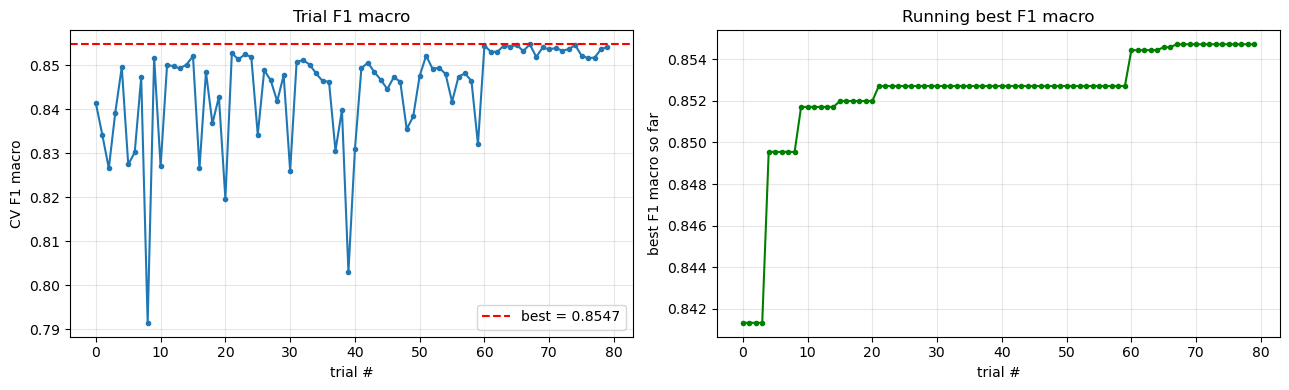

In [12]:
# Optuna study diagnostics - the value plot shows whether more trials would help.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vals = [t.value for t in study.trials if t.value is not None]
ax[0].plot(vals, marker=".")
ax[0].axhline(study.best_value, color="red", ls="--", label=f"best = {study.best_value:.4f}")
ax[0].set(title="Trial F1 macro", xlabel="trial #", ylabel="CV F1 macro")
ax[0].legend()
ax[0].grid(alpha=0.3)

running_best = np.maximum.accumulate(vals)
ax[1].plot(running_best, marker=".", color="green")
ax[1].set(title="Running best F1 macro", xlabel="trial #", ylabel="best F1 macro so far")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Train the final model on all of the training data

Re-fit a fresh CatBoost with the Optuna-selected hyper-parameters on the entire training set, then inspect the in-sample report. (The honest performance estimate is the CV F1 macro above and the out-of-fold scores in section 9 - this section is just a sanity check.)

In [13]:
best_model = CatBoostClassifier(
    **study.best_params,
    eval_metric="TotalF1",
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)
final_pipe = Pipeline([("prep", preprocessor), ("model", best_model)])
final_pipe.fit(X, y)

train_preds = final_pipe.predict(X)
train_probs = final_pipe.predict_proba(X)[:, 1]

print(f"Training F1 macro : {f1_score(y, train_preds, average='macro'):.4f}")
print(f"Training accuracy : {accuracy_score(y, train_preds):.4f}")
print(f"Training AUC      : {roc_auc_score(y, train_probs):.4f}")
print("\nConfusion matrix (train):")
print(confusion_matrix(y, train_preds))
print("\nClassification report (train):")
print(classification_report(y, train_preds, digits=4))

Training F1 macro : 0.9118
Training accuracy : 0.9118
Training AUC      : 0.9727

Confusion matrix (train):
[[3163  289]
 [ 324 3178]]

Classification report (train):
              precision    recall  f1-score   support

           0     0.9071    0.9163    0.9117      3452
           1     0.9166    0.9075    0.9120      3502

    accuracy                         0.9118      6954
   macro avg     0.9119    0.9119    0.9118      6954
weighted avg     0.9119    0.9118    0.9119      6954



## 8. Feature importances and churn drivers

The chart below ranks features by CatBoost's `PredictionValuesChange` importance - i.e. how much the model's prediction would change on average if a given feature were perturbed.

Conceptually the drivers fall into three groups:

1. **Engagement signals** - `LoyaltyPoints`, `SurveyScore`, `DaysSinceEmail`. These quantify a guest's existing relationship with the resort. Lower loyalty balances, lower survey scores, and longer email gaps all push toward churn.
2. **Spend behaviour** - `TotalSpend_log`, the individual `<amenity>_log` columns, and `SpendCategories` (how many different amenities the guest used). Guests who engage with more amenity categories and spend more across them are stickier.
3. **Booking + demographic context** - `DaysSinceFirstBooking`, `BookingMonth`, `Age` / `AgeGroup`, `Region`, `PackageType`, and `BookingChannel`. These capture *who* the guest is and *when / how* they booked, which carries weaker but still meaningful signal.

Categorical one-hot columns appear individually in the chart (e.g. `cat__BookingChannel_Mobile`); the *underlying* categorical fields are usually more important than any single level suggests, because their importance is spread across multiple one-hot columns.

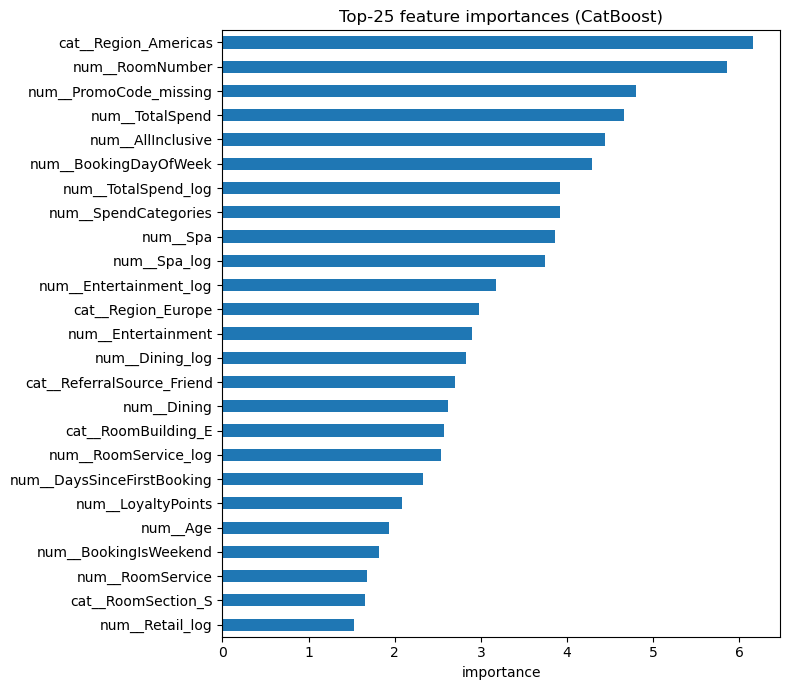

In [14]:
# Top-25 feature importances from the tuned CatBoost model (PredictionValuesChange).
feature_names = final_pipe.named_steps["prep"].get_feature_names_out()
importances = final_pipe.named_steps["model"].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 7))
fi[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top-25 feature importances (CatBoost)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

In [15]:
fi_full = pd.Series(importances, index=feature_names).sort_values(ascending=False)
fi_table = pd.DataFrame({
    "rank":           np.arange(1, len(fi_full) + 1),
    "feature":        fi_full.index,
    "importance":     fi_full.values.round(3),
    "importance_pct": (fi_full.values / fi_full.values.sum() * 100).round(2),
}).head(15).reset_index(drop=True)
print("Top 15 features by CatBoost PredictionValuesChange importance:")
fi_table

Top 15 features by CatBoost PredictionValuesChange importance:


,rank,feature,importance,importance_pct
0,1,cat__Region_Americas,6.163,6.16
1,2,num__RoomNumber,5.854,5.85
2,3,num__PromoCode_missing,4.804,4.80
3,4,num__TotalSpend,4.658,4.66
4,5,num__AllInclusive,4.437,4.44
5,6,num__BookingDayOfWeek,4.286,4.29
6,7,num__TotalSpend_log,3.923,3.92
7,8,num__SpendCategories,3.915,3.92
8,9,num__Spa,3.854,3.85
9,10,num__Spa_log,3.744,3.74


In [16]:
fi_low_table = pd.DataFrame({
    "rank":           np.arange(1, len(fi_full) + 1),
    "feature":        fi_full.index,
    "importance":     fi_full.values.round(3),
    "importance_pct": (fi_full.values / fi_full.values.sum() * 100).round(2),
}).tail(15).reset_index(drop=True)
print("Bottom 15 features by CatBoost PredictionValuesChange importance:")
fi_low_table

Bottom 15 features by CatBoost PredictionValuesChange importance:


,rank,feature,importance,importance_pct
0,63,cat__ReferralSource_Google,0.038,0.04
1,64,cat__ReferralSource_Magazine,0.031,0.03
2,65,cat__ReferralSource_LinkedIn,0.027,0.03
3,66,cat__RoomSection_None,0.022,0.02
4,67,cat__ReferralSource_TV,0.019,0.02
5,68,cat__BookingChannel_Mobile,0.013,0.01
6,69,cat__AgeGroup_Middle,0.011,0.01
7,70,cat__ReferralSource_Pinterest,0.004,0.00
8,71,cat__RoomBuilding_B,0.000,0.00
9,72,cat__RoomBuilding_D,0.000,0.00


## 9. Choosing the decision threshold (out-of-fold)

The model is **built on the default 0.5 rule** - that is what Optuna optimised and what `final_pipe` predicts. The operating threshold is a *post-hoc* choice, so we make it on **out-of-fold** probabilities (`cross_val_predict` - every row is scored by a model that never saw it) and compare two rules on the *same* probabilities:

* **baseline** - `predict 1 iff p >= 0.5`.
* **tuned monotonic cut** - sweep a single `tau` and keep the value that maximises macro F1 (`predict 1 iff p >= tau`).

The tuned cut keeps high probability = churn and edges slightly **above** baseline. (The `tau` is tuned on the same out-of-fold probabilities it is scored on, so treat its gain as a small, mildly optimistic estimate.)

In [17]:
def tune_threshold(p_churn, y_true, grid=None):
    """Sweep a single monotonic cut tau (predict 1 iff p >= tau) and return the
    tau that maximises macro F1, plus the full (grid, scores) arrays for plotting.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 181)
    scores = np.array([
        f1_score(y_true, (p_churn >= t).astype(int), average="macro") for t in grid
    ])
    best = int(scores.argmax())
    return grid[best], scores[best], grid, scores

In [18]:
# Out-of-fold probabilities from the tuned pipeline (leak-free): every row is
# scored by a model trained on the other four folds.
oof_probs = cross_val_predict(final_pipe, X, y, cv=cv, n_jobs=-1,
                              method="predict_proba")[:, 1]

# Baseline 0.5 rule vs a tuned monotonic cut, on the SAME out-of-fold probabilities.
preds_baseline = (oof_probs >= 0.5).astype(int)
correct_mask   = (preds_baseline == y)                  # reused by the plot + section 10
BEST_TAU, f1_tuned, tau_grid, tau_scores = tune_threshold(oof_probs, y)
preds_tuned    = (oof_probs >= BEST_TAU).astype(int)

f1_baseline = f1_score(y, preds_baseline, average="macro")

comparison = pd.DataFrame({
    "rule":     ["baseline (p >= 0.5)", f"tuned monotonic (p >= {BEST_TAU:.3f})"],
    "f1_macro": [f1_baseline, f1_tuned],
})
comparison["delta_vs_baseline"] = comparison["f1_macro"] - f1_baseline
print("Out-of-fold threshold comparison (model built on the default 0.5 rule):")
print(comparison.round(4).to_string(index=False))

print(f"\nChosen rule for submission: tuned monotonic cut at p_churn >= {BEST_TAU:.3f}")
print("\nConfusion matrix - tuned threshold (rows=actual, cols=predicted):")
print(confusion_matrix(y, preds_tuned))
print("\nClassification report - tuned threshold:")
print(classification_report(y, preds_tuned, target_names=["kept", "churned"], digits=4))

Out-of-fold threshold comparison (model built on the default 0.5 rule):
                        rule  f1_macro  delta_vs_baseline
         baseline (p >= 0.5)    0.8548             0.0000
tuned monotonic (p >= 0.490)    0.8552             0.0004

Chosen rule for submission: tuned monotonic cut at p_churn >= 0.490

Confusion matrix - tuned threshold (rows=actual, cols=predicted):
[[2969  483]
 [ 524 2978]]

Classification report - tuned threshold:
              precision    recall  f1-score   support

        kept     0.8500    0.8601    0.8550      3452
     churned     0.8604    0.8504    0.8554      3502

    accuracy                         0.8552      6954
   macro avg     0.8552    0.8552    0.8552      6954
weighted avg     0.8553    0.8552    0.8552      6954



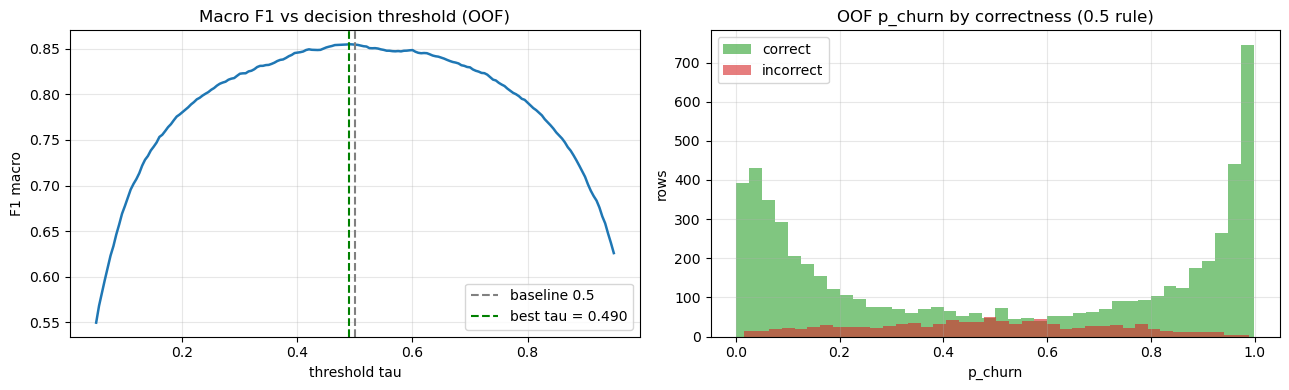

In [19]:
# Left: macro F1 across all candidate thresholds. Right: the TRUE spread of
# out-of-fold p_churn for correct vs incorrect predictions - note how many
# correct predictions sit in the uncertain middle, not just at the extremes.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(tau_grid, tau_scores, lw=1.8)
ax[0].axvline(0.5, color="gray", ls="--", label="baseline 0.5")
ax[0].axvline(BEST_TAU, color="green", ls="--", label=f"best tau = {BEST_TAU:.3f}")
ax[0].set(title="Macro F1 vs decision threshold (OOF)",
          xlabel="threshold tau", ylabel="F1 macro")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].hist(oof_probs[correct_mask],  bins=40, alpha=0.6, color="tab:green", label="correct")
ax[1].hist(oof_probs[~correct_mask], bins=40, alpha=0.6, color="tab:red",   label="incorrect")
ax[1].set(title="OOF p_churn by correctness (0.5 rule)",
          xlabel="p_churn", ylabel="rows")
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Native categorical handling (measured experiment)

One-hot encoding bypasses CatBoost's built-in categorical machinery. This section measures the alternative: hand the 8 categorical columns straight to CatBoost via `cat_features` (NaN filled with an explicit `"missing"` level), let it build its own category combinations and leak-safe ordered target statistics (CTR), and let it handle numeric NaNs natively too - no `ColumnTransformer`, no scaling.

To isolate the effect we hold the hyper-parameters fixed at the section 5 defaults - only the categorical handling changes - and score 5-fold out-of-fold F1 macro. (CatBoost's `cat_features` does not round-trip through `sklearn.clone`, so the native side uses a manual CV loop instead of `cross_val_predict`.) Expect a result inside the fold noise: native categoricals are the only variant that has edged the one-hot baseline at all, and only by a hair. A native-specific Optuna retune - it exposes knobs like `one_hot_max_size` and the CTR settings that one-hot can't use - is the follow-up if the gap looks worth chasing.

In [20]:
# Same default hyper-parameters as the section 5 baseline, so the ONLY thing that
# changes between the two pipelines is one-hot vs native categorical handling.
DEFAULT_CB = dict(iterations=400, depth=6, learning_rate=0.05,
                  random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False)

# One-hot OOF probabilities (pooled) via the existing preprocessor pipeline.
oh_pipe = Pipeline([("prep", preprocessor), ("model", CatBoostClassifier(**DEFAULT_CB))])
oof_oh = cross_val_predict(oh_pipe, X, y, cv=cv, n_jobs=-1, method="predict_proba")[:, 1]

# Native categorical inputs: fill categorical NaN with an explicit "missing" level;
# numerics keep their NaNs (CatBoost handles them natively). No one-hot, no scaling.
X_native = X.copy()
X_native[categorical_cols] = X_native[categorical_cols].fillna("missing").astype(str)
cat_feature_idx = [X_native.columns.get_loc(c) for c in categorical_cols]

# Native OOF probabilities (pooled) via a manual CV loop on the SAME folds.
# (cat_features breaks sklearn.clone, so cross_val_predict cannot be used here.)
oof_native = np.zeros(len(y))
for tr, te in cv.split(X_native, y):
    m = CatBoostClassifier(**DEFAULT_CB, cat_features=cat_feature_idx)
    m.fit(X_native.iloc[tr], y[tr])
    oof_native[te] = m.predict_proba(X_native.iloc[te])[:, 1]

f1_oh     = f1_score(y, (oof_oh     >= 0.5).astype(int), average="macro")
f1_native = f1_score(y, (oof_native >= 0.5).astype(int), average="macro")
print("5-fold OOF F1 macro at fixed default params (only categorical handling differs):")
print(f"  one-hot encoder      : {f1_oh:.4f}")
print(f"  native cat_features  : {f1_native:.4f}")
print(f"  delta (native - oh)  : {f1_native - f1_oh:+.4f}")

5-fold OOF F1 macro at fixed default params (only categorical handling differs):
  one-hot encoder      : 0.8533
  native cat_features  : 0.8540
  delta (native - oh)  : +0.0007


## 11. Worked examples - a random sample of correct and incorrect predictions

A **random sample** of 5 correctly-classified and 5 misclassified out-of-fold rows (and 100 of each written to `worked_examples.csv`).

These used to be the *most-confident* rows of each group, which made correct predictions look like they always sit at the extremes (`p_churn` near 0 or 1) - a selection artifact, since high confidence was the very thing being selected for. A random sample shows the true spread: plenty of correct predictions sit in the uncertain middle, not just at the extremes.

In [21]:
rng = np.random.default_rng(RANDOM_STATE)

# Use the model's natural 0.5-rule predictions (reusing correct_mask from section 9).
oof_preds  = preds_baseline
confidence = np.where(oof_preds == 1, oof_probs, 1 - oof_probs)

correct_idx = np.where(correct_mask)[0]
wrong_idx   = np.where(~correct_mask)[0]

# RANDOM samples (not top-by-confidence), so the examples are representative of
# the whole population rather than just the most extreme rows.
sample_correct = np.sort(rng.choice(correct_idx, size=5, replace=False))
sample_wrong   = np.sort(rng.choice(wrong_idx,   size=5, replace=False))

display_cols = [
    "GuestID", "Region", "PackageType", "AgeGroup", "VIP",
    "TotalSpend", "SpendCategories", "LoyaltyPoints", "SurveyScore",
    "DaysSinceEmail", "BookingChannel", "ReferralSource",
]

def example_table(row_indices):
    out = train_fe.iloc[row_indices][display_cols].copy()
    out.insert(0, "actual",    y[row_indices])
    out.insert(1, "predicted", oof_preds[row_indices])
    out.insert(2, "p_churn",   oof_probs[row_indices].round(3))
    return out.reset_index(drop=True)

print("FIVE RANDOM CORRECT PREDICTIONS")
print("=" * 70)
print(example_table(sample_correct).to_string(index=False))

print("\nFIVE RANDOM INCORRECT PREDICTIONS")
print("=" * 70)
print(example_table(sample_wrong).to_string(index=False))

# Random 100 of each group (or all, if fewer) for offline inspection.
N_EXPORT = 100
export_correct = rng.choice(correct_idx, size=min(N_EXPORT, len(correct_idx)), replace=False)
export_wrong   = rng.choice(wrong_idx,   size=min(N_EXPORT, len(wrong_idx)),   replace=False)

def export_table(row_indices, group_label):
    out = train_fe.iloc[row_indices].copy()
    out.insert(0, "group",      group_label)
    out.insert(1, "actual",     y[row_indices])
    out.insert(2, "predicted",  oof_preds[row_indices])
    out.insert(3, "p_churn",    oof_probs[row_indices])
    out.insert(4, "confidence", confidence[row_indices])
    return out.reset_index(drop=True)

worked_examples = pd.concat(
    [export_table(export_correct, "correct"),
     export_table(export_wrong,   "incorrect")],
    ignore_index=True,
)
WORKED_PATH = "worked_examples.csv"
worked_examples.to_csv(WORKED_PATH, index=False)

corr_p = worked_examples.loc[worked_examples.group == "correct", "p_churn"]
print(f"\nWrote {WORKED_PATH}: "
      f"{(worked_examples['group'] == 'correct').sum()} correct + "
      f"{(worked_examples['group'] == 'incorrect').sum()} incorrect rows "
      f"(random sample, {worked_examples.shape[1]} columns)")
print(f"p_churn in the random 'correct' sample spans [{corr_p.min():.3f}, {corr_p.max():.3f}] "
      f"- the full range, unlike the old most-confident export.")

FIVE RANDOM CORRECT PREDICTIONS
 actual  predicted  p_churn  GuestID   Region PackageType AgeGroup  VIP  TotalSpend  SpendCategories  LoyaltyPoints  SurveyScore  DaysSinceEmail BookingChannel ReferralSource
      0          0    0.318   367834 Americas  Relaxation    Minor  0.0        1226                3           2530            1             109    TravelAgent    TripAdvisor
      1          1    0.854   808653 Americas  Relaxation    Minor  0.0           0                0           9562            1             359      Corporate      Instagram
      0          0    0.306   559555 Americas   Adventure    Minor  0.0           0                0           4675            5             118          Phone          Email
      0          0    0.174   159760 Americas  Relaxation    Young  0.0         789                2            339            1             166        Website         Google
      0          0    0.483   895312 Americas    Wellness    Young  0.0           0          

## 12. Predict on the test set + write `submission.csv`

Apply the **tuned monotonic threshold** chosen in section 9 to the test-set probabilities and write the two-column `GuestID,Churned` file next to the notebook. (Swap the one prediction line if you would rather use the plain 0.5 rule.)

In [22]:
# Submission uses the tuned monotonic threshold from section 9 (best OOF macro F1).
# For the plain 0.5 rule instead, use:  test_preds = (test_probs >= 0.5).astype(int)
test_probs = final_pipe.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= BEST_TAU).astype(int)

submission = pd.DataFrame({
    "GuestID": test_fe[ID_COL].values,
    "Churned": test_preds,
})
submission.to_csv("submission.csv", index=False)

print(f"Wrote submission.csv with {len(submission)} rows")
print(f"Decision threshold used : p_churn >= {BEST_TAU:.3f}  (tuned in section 9)")
print(f"Predicted churn rate    : {submission['Churned'].mean():.2%}")
submission.head()

Wrote submission.csv with 1739 rows
Decision threshold used : p_churn >= 0.490  (tuned in section 9)
Predicted churn rate    : 48.71%


,GuestID,Churned
0,154038,1
1,620160,0
2,655103,0
3,126993,1
4,635228,0


## 13. Notes for future iterations

* **Decision threshold.** Section 9 builds the model on the default 0.5 rule, then chooses the operating threshold on out-of-fold probabilities. The tuned monotonic cut typically beats the 0.5 baseline only marginally (a fraction of a point) because a well-calibrated, class-balanced model is already near-optimal at 0.5.
* **Native categorical handling (section 10).** Passing categoricals to CatBoost via `cat_features` lands within fold noise of the one-hot pipeline at fixed hyper-parameters (a touch above at default params). To chase it, give the native model its own Optuna study - it exposes extra knobs (`one_hot_max_size`, CTR settings) the one-hot pipeline cannot use. Hand-engineered features (spend shares/concentration, room floor/position) were tested and did **not** beat baseline - the signal is already captured.
* **Worked examples are a random sample.** They were previously the most-confident rows of each group, which made correct predictions look like they always sit at the extremes. That was a selection artifact; the random sample shows the true spread.
* **More trials.** TPE keeps improving with more samples. Doubling `N_TRIALS` usually nudges F1 macro up without changing the search space.
* **Stacking.** Blend the CatBoost with a different family (a tuned linear model or `HistGradientBoosting`) - models that disagree on different rows tend to average out to a small macro-F1 gain.
* **Accept the ceiling.** Across two ablation rounds nothing hand-engineered moved the needle past ~0.853; that may simply be the limit of these features, in which case the remaining gains are in more data or external signal rather than modelling.